# Patent Disruption — Granted vs Extended (granted + application) citation network

Compares the two disruption tables produced by this project:

| table | notebook | citation network |
|---|---|---|
| `output/patent_disruption.parquet` | `patent_disruption.ipynb` | **granted only** — `g_us_patent_citation`, utility↔utility |
| `output/patent_disruption_app.parquet` | `patent_disruption_app_add.ipynb` | **extended** — granted ∪ application citations (`g_us_application_citation`, cited pgpub mapped to a granted `patent_id` through `pg_granted_pgpubs_crosswalk`), directed pairs de-duplicated after the union |

Both share the schema `patent_id` + `{CD, F, E, G, ni, nj, nk}` × window `{_3, _5, _10, _all}`.
Throughout, **granted / `_b`** = `patent_disruption.parquet` and **extended / `_a`** = `patent_disruption_app.parquet`.
The headline window is **5 years**.

**What to expect.** Application citations only ever *add* edges, so for a patent present in both tables its
citer count `ni + nj` and its `nk` can only rise. Which way
$\mathrm{CD}=\frac{n_i-n_j}{n_i+n_j+n_k}$ moves is the open question: added citers that share none of the
focal patent's references push CD up, added co-citers and added `nk` push it down. Pre-grant publication of
applications began in **2001** (AIPA), so the two networks should be the same graph for older patents and
diverge from the early 2000s onward.

**Directories**

```
notebook : /project/jevans/Dawoon/Science of Science/PatentView/notebook/patent_disruption_app_compare.ipynb
inputs   : /project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption.parquet
           /project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption_app.parquet
           /project/jevans/Dawoon/Science of Science/PatentView/output/patent_metadata.parquet   (grant_year, cpc_code)
output   : /project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption_compare.parquet
```

The two disruption tables are read-only here; the single file written is the per-window summary in section 9.

> **Why this notebook does not just `read_parquet` both tables and `merge`.** On a Midway **login node** the
> user cgroup is capped at **8 GiB** (`/sys/fs/cgroup/memory/user.slice/user-<uid>.slice/memory.limit_in_bytes`),
> and holding two ~8.5M × 29 tables plus a pandas string merge is well past that — the kernel gets OOM-killed
> mid-run with no traceback. So the two tables are aligned **once** into integer row positions using an Arrow
> dictionary over `patent_id`, and metric columns are pulled one at a time. Peak resident memory is ~2 GB,
> and the notebook runs on a login node as-is. On a compute node with more memory it works unchanged.

In [1]:
import os, sys, gc, time, resource
import numpy as np, pandas as pd
import pyarrow as pa, pyarrow.parquet as pq, pyarrow.compute as pc
sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/PatentView')
import pv_common as pv
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
# inline, not Agg: the figures are the point of this notebook and should be visible in it.
# run_notebook.py strips magics, and its sbatch sets MPLBACKEND=Agg instead.

WSFX = ['_3', '_5', '_10', '_all']
MET  = ['CD', 'F', 'E', 'G', 'ni', 'nj', 'nk']
MAIN = '_5'                        # headline window
C_B, C_A, C_D = '#333333', '#e377c2', '#8172b3'   # granted / extended / delta, used in every figure

BASE_FP = pv.out('patent_disruption.parquet')
APP_FP  = pv.out('patent_disruption_app.parquet')
META_FP = pv.out('patent_metadata.parquet')
CMP_FP  = pv.out('patent_disruption_compare.parquet')

def rss_gb():
    return resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1e6   # peak RSS, kB -> GB

_cache, _CACHE_MAX = {}, 16
def col(fp, name):
    # One column as a float32 numpy array (nulls -> NaN), with a small FIFO cache.
    # Each column is 8.5M float32 = ~34 MB and a re-read costs about a second, so a
    # 16-entry cache (~550 MB) keeps the repeated reads cheap while staying far inside
    # the 8 GiB login-node cgroup. Unbounded, all 56 metric columns would pin ~2 GB.
    k = (fp, name)
    if k not in _cache:
        if len(_cache) >= _CACHE_MAX:
            _cache.pop(next(iter(_cache)))
        _cache[k] = pq.read_table(fp, columns=[name]).column(name).combine_chunks(
                        ).to_numpy(zero_copy_only=False)
    return _cache[k]

for fp in (BASE_FP, APP_FP, META_FP):
    print(f'{os.path.getsize(fp)/1e9:5.2f} GB  {fp}')
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
pd.set_option('display.max_columns', 50); pd.set_option('display.width', 200)
print(f'\npeak RSS so far: {rss_gb():.2f} GB')

 0.25 GB  /project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption.parquet
 0.32 GB  /project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption_app.parquet
 0.87 GB  /project/jevans/Dawoon/Science of Science/PatentView/output/patent_metadata.parquet

peak RSS so far: 0.16 GB


## 1. Align the two tables

`patent_id` is not numeric (design reissues appear as e.g. `RE34947`), so the join key is the string.
Concatenating the three id columns and dictionary-encoding them once gives every distinct patent an
integer code; from those codes we build, for each table, `pos[code] -> row number` (`-1` = absent).
Everything downstream is then a numpy fancy-index, with no string comparison and no pandas merge.

In [2]:
t0 = time.time()
def ids(fp):
    return pq.read_table(fp, columns=['patent_id']).column('patent_id').combine_chunks().cast(pa.string())

b_ids, a_ids, m_ids = ids(BASE_FP), ids(APP_FP), ids(META_FP)
n_b, n_a, n_m = len(b_ids), len(a_ids), len(m_ids)
enc = pc.dictionary_encode(pa.concat_arrays([b_ids, a_ids, m_ids]))
del b_ids, a_ids, m_ids; gc.collect()
codes = enc.indices.to_numpy(zero_copy_only=False).astype(np.int64)
uni   = enc.dictionary                       # every distinct patent_id, kept for the tables in section 8
n_u   = len(uni); del enc; gc.collect()

k_b, k_a, k_m = codes[:n_b], codes[n_b:n_b + n_a], codes[n_b + n_a:]
pos_b = np.full(n_u, -1, np.int64); pos_b[k_b] = np.arange(n_b)
pos_a = np.full(n_u, -1, np.int64); pos_a[k_a] = np.arange(n_a)
pos_m = np.full(n_u, -1, np.int64); pos_m[k_m] = np.arange(n_m)
del codes, k_b, k_a, k_m; gc.collect()

in_b, in_a = pos_b >= 0, pos_a >= 0
both_code = np.flatnonzero(in_b & in_a)      # patent codes present in BOTH tables
ub, ua    = pos_b[both_code], pos_a[both_code]   # aligned row numbers into base / app
n_both    = len(both_code)
print(f'[{time.time()-t0:.0f}s] base {n_b:,} rows | app {n_a:,} rows | meta {n_m:,} rows | '
      f'{n_u:,} distinct patent_id')
print(f'peak RSS: {rss_gb():.2f} GB')

# grant_year and CPC section for the shared patents, aligned to `both_code`.
pm = pos_m[both_code]
gy_all = pq.read_table(META_FP, columns=['grant_year']).column('grant_year').combine_chunks(
             ).to_numpy(zero_copy_only=False)
gyear = np.where(pm >= 0, gy_all[np.clip(pm, 0, None)], -1).astype(np.int32); del gy_all
cpc_all = pq.read_table(META_FP, columns=['cpc_code']).column('cpc_code').combine_chunks()
sect_all = pc.utf8_slice_codeunits(pc.cast(cpc_all, pa.string()), 0, 1).to_numpy(zero_copy_only=False)
sect = np.where(pm >= 0, sect_all[np.clip(pm, 0, None)], None).astype('U1')
sect[~np.isin(sect, list('ABCDEFGHY'))] = ''
del cpc_all, sect_all, pm; gc.collect()
print(f'grant_year known for {100*(gyear>0).mean():.1f}% of shared patents, '
      f'CPC section for {100*(sect!="").mean():.1f}%')

[7s] base 8,062,166 rows | app 8,460,168 rows | meta 8,531,961 rows | 8,531,961 distinct patent_id
peak RSS: 1.70 GB


grant_year known for 100.0% of shared patents, CPC section for 99.8%


## 2. Coverage — which patents are in which table

The two tables do **not** have the same row set. A row exists for every patent that appears anywhere in
its network (as citer or as cited), so patents reachable only through an application citation appear in
`app` and not in `base`. The reverse should be empty: the extended network has a superset of the edges,
hence a superset of the nodes.

in base only : 0   (as expected: none)
in app  only : 398,002   <- reachable only through an application citation
in both      : 8,062,166
union        : 8,460,168

app-only patents by grant year (pre-grant publication starts 2001):


,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
app_only_patents,4,65,142,218,310,573,676,929,1389,2305,3320,5042,7190,9850,12767,15898,18599,21329,28409,32472,34689,43644,42835,53527,61820


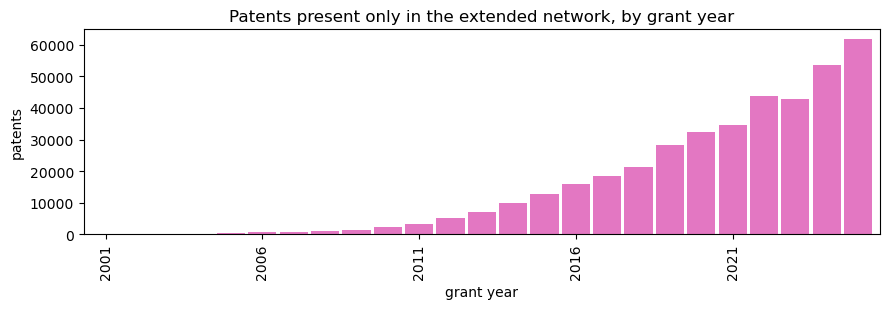

,base_CD_defined,app_CD_defined,base_CD_defined%,app_CD_defined%
window,,,,
_3,5606555,6897644,69.5415,81.5308
_5,5768230,7011553,71.5469,82.8772
_10,5899905,7114532,73.1801,84.0945
_all,5973424,7186006,74.0920,84.9393


In [3]:
n_only_b = int((in_b & ~in_a).sum())
n_only_a = int((in_a & ~in_b).sum())
print(f'in base only : {n_only_b:,}'
      + ('   <- unexpected: extended should be a node superset' if n_only_b else '   (as expected: none)'))
print(f'in app  only : {n_only_a:,}   <- reachable only through an application citation')
print(f'in both      : {n_both:,}')
print(f'union        : {int((in_b | in_a).sum()):,}')

if n_only_a:
    oa = np.flatnonzero(in_a & ~in_b)
    pm_o = pos_m[oa]
    gy_all = pq.read_table(META_FP, columns=['grant_year']).column('grant_year').combine_chunks(
                 ).to_numpy(zero_copy_only=False)
    gy_o = gy_all[pm_o[pm_o >= 0]]; del gy_all
    vc = pd.Series(gy_o).value_counts().sort_index()
    print(f'\napp-only patents by grant year (pre-grant publication starts 2001):')
    display(vc[vc.index >= 1995].to_frame('app_only_patents').T)
    fig, ax = plt.subplots(figsize=(9, 3.2))
    vc[(vc.index >= 1976) & (vc.index <= 2025)].plot.bar(ax=ax, color=C_A, width=0.9)
    ax.set_title('Patents present only in the extended network, by grant year')
    ax.set_xlabel('grant year'); ax.set_ylabel('patents')
    ax.set_xticks(ax.get_xticks()[::5]); plt.tight_layout(); plt.show()
    del oa, pm_o, gy_o

# CD is NaN when a patent has no citers inside the window, so "defined %" is itself a
# coverage statement about each network.
rows = []
for s in WSFX:
    cb, ca = col(BASE_FP, f'CD{s}'), col(APP_FP, f'CD{s}')
    rows.append({'window': s,
                 'base_CD_defined': int((~np.isnan(cb)).sum()), 'app_CD_defined': int((~np.isnan(ca)).sum()),
                 'base_CD_defined%': 100 * (~np.isnan(cb)).mean(), 'app_CD_defined%': 100 * (~np.isnan(ca)).mean()})
display(pd.DataFrame(rows).set_index('window'))

## 3. Summary — means by window, base vs extended

Means over each table's own rows, which is what you would report using either file on its own.
From section 4 onward everything is restricted to the patents present in both, so the shift is never
confounded by the differing row sets.

In [4]:
rows = []
for s in WSFX:
    for m in MET:
        b, a = col(BASE_FP, f'{m}{s}'), col(APP_FP, f'{m}{s}')
        mb, ma = np.nanmean(b), np.nanmean(a)
        rows.append({'window': s, 'metric': m, 'base_mean': mb, 'app_mean': ma, 'delta': ma - mb,
                     'delta%': 100 * (ma - mb) / abs(mb) if mb else np.nan,
                     'base_defined%': 100 * (~np.isnan(b)).mean(),
                     'app_defined%': 100 * (~np.isnan(a)).mean()})
tab = pd.DataFrame(rows)

print('--- CD ---')
display(tab[tab['metric'] == 'CD'].set_index('window').drop(columns='metric'))
print('--- ni / nj / nk  (network density) ---')
display(tab[tab['metric'].isin(['ni', 'nj', 'nk'])]
        .pivot(index='window', columns='metric', values=['base_mean', 'app_mean', 'delta']).reindex(WSFX))
print('--- F / E / G  (shares of the citers, sum to 1) ---')
display(tab[tab['metric'].isin(['F', 'E', 'G'])]
        .pivot(index='window', columns='metric', values=['base_mean', 'app_mean', 'delta']).reindex(WSFX))
print(f'peak RSS: {rss_gb():.2f} GB')

--- CD ---


,base_mean,app_mean,delta,delta%,base_defined%,app_defined%
window,,,,,,
_3,0.0933,0.0618,-0.0315,-33.8101,69.5415,81.5308
_5,0.1240,0.0817,-0.0423,-34.1236,71.5469,82.8772
_10,0.1517,0.1020,-0.0497,-32.7537,73.1801,84.0945
_all,0.1691,0.1173,-0.0518,-30.6264,74.0920,84.9393


--- ni / nj / nk  (network density) ---


base_mean                 app_mean                  delta                
metric        ni     nj       nk       ni     nj       nk     ni     nj       nk
window                                                                          
_3        1.2209 1.1026 157.2457   2.0467 2.0839 234.1336 0.8259 0.9813  76.8880
_5        2.4231 2.0627 218.7269   3.6216 3.4034 321.2261 1.1985 1.3407 102.4993
_10       5.2537 4.3464 331.9571   6.9172 6.1149 459.9770 1.6635 1.7685 128.0199
_all     11.5500 8.4211 442.9681  12.6732 9.8435 562.3713 1.1232 1.4224 119.4032

--- F / E / G  (shares of the citers, sum to 1) ---


base_mean               app_mean                 delta               
metric         E      F      G        E      F      G       E      F       G
window                                                                      
_3        0.3726 0.0254 0.6020   0.3673 0.0717 0.5611 -0.0053 0.0462 -0.0409
_5        0.3414 0.0514 0.6072   0.3356 0.1046 0.5597 -0.0057 0.0532 -0.0475
_10       0.3037 0.1060 0.5903   0.2959 0.1662 0.5379 -0.0078 0.0602 -0.0524
_all      0.2666 0.1851 0.5484   0.2598 0.2456 0.4946 -0.0067 0.0605 -0.0538

peak RSS: 1.70 GB


## 4. Window 5 — the CD shift, patent by patent

Restricted to patents with `CD_5` defined in **both** tables, so every number below is a paired
comparison of the same patent under two networks.

patents with CD_5 defined in both: 5,768,230  (of 8,062,166 shared, 71.5%)
mean   CD_5  granted +0.1240  ->  extended +0.0860   (delta -0.0379)
median CD_5  granted +0.0043  ->  extended +0.0039
sd     CD_5  granted 0.3117   ->  extended 0.2543

more consolidating (CD falls) :  26.9%
more disruptive    (CD rises) :  22.2%
unchanged                     :  51.0%
|delta| > 0.05                :  15.8%
|delta| > 0.20                :   7.0%



Pearson  CD_5 granted vs extended: 0.7831


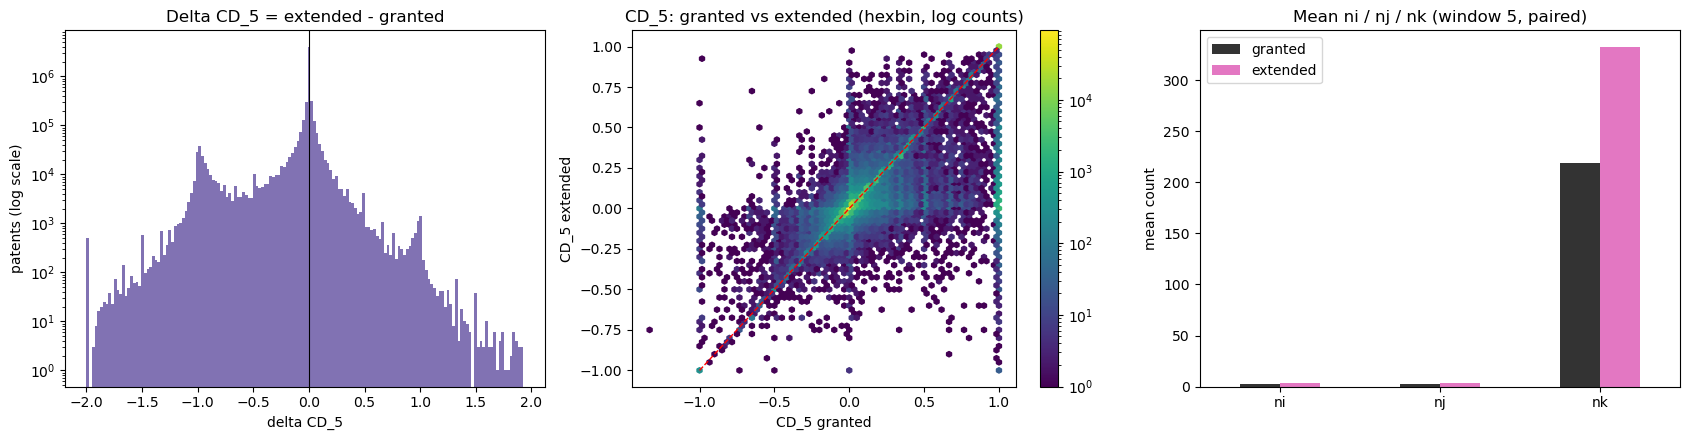

,granted,extended,delta,pct
ni,2.4231,3.8867,1.4635,60.3986
nj,2.0627,3.8540,1.7913,86.8416
nk,218.7269,332.3624,113.6354,51.9531


In [5]:
def paired(name, s=MAIN):
    # Aligned (granted, extended) arrays of one metric over the patents in both tables.
    return col(BASE_FP, f'{name}{s}')[ub], col(APP_FP, f'{name}{s}')[ua]

CDb, CDa = paired('CD')
ok = ~np.isnan(CDb) & ~np.isnan(CDa)          # defined in both
cb, ca = CDb[ok], CDa[ok]
dd = ca - cb
print(f'patents with CD{MAIN} defined in both: {ok.sum():,}  '
      f'(of {n_both:,} shared, {100*ok.mean():.1f}%)')
print(f'mean   CD{MAIN}  granted {cb.mean():+.4f}  ->  extended {ca.mean():+.4f}   (delta {dd.mean():+.4f})')
print(f'median CD{MAIN}  granted {np.median(cb):+.4f}  ->  extended {np.median(ca):+.4f}')
print(f'sd     CD{MAIN}  granted {cb.std():.4f}   ->  extended {ca.std():.4f}')
print()
print(f'more consolidating (CD falls) : {100*(dd<0).mean():5.1f}%')
print(f'more disruptive    (CD rises) : {100*(dd>0).mean():5.1f}%')
print(f'unchanged                     : {100*(dd==0).mean():5.1f}%')
print(f'|delta| > 0.05                : {100*(np.abs(dd)>0.05).mean():5.1f}%')
print(f'|delta| > 0.20                : {100*(np.abs(dd)>0.20).mean():5.1f}%')
print()
print(f'Pearson  CD{MAIN} granted vs extended: {np.corrcoef(cb, ca)[0,1]:.4f}')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].hist(dd, bins=160, color=C_D)
ax[0].axvline(0, color='k', lw=0.8); ax[0].set_yscale('log')
ax[0].set_title(f'Delta CD{MAIN} = extended - granted')
ax[0].set_xlabel(f'delta CD{MAIN}'); ax[0].set_ylabel('patents (log scale)')

rng = np.random.default_rng(0)
smp = rng.choice(len(cb), size=min(300_000, len(cb)), replace=False)
hb = ax[1].hexbin(cb[smp], ca[smp], gridsize=70, bins='log', cmap='viridis')
ax[1].plot([-1, 1], [-1, 1], 'r--', lw=1)
ax[1].set_xlabel(f'CD{MAIN} granted'); ax[1].set_ylabel(f'CD{MAIN} extended')
ax[1].set_title(f'CD{MAIN}: granted vs extended (hexbin, log counts)')
fig.colorbar(hb, ax=ax[1])

nmeans = {}
for nm in ['ni', 'nj', 'nk']:
    xb, xa = paired(nm)
    nmeans[nm] = (np.nanmean(xb[ok]), np.nanmean(xa[ok]))
means = pd.DataFrame(nmeans, index=['granted', 'extended']).T
means.plot.bar(ax=ax[2], color=[C_B, C_A])
ax[2].set_title(f'Mean ni / nj / nk (window {MAIN.strip("_")}, paired)')
ax[2].set_ylabel('mean count'); ax[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

display(means.assign(delta=lambda t: t['extended'] - t['granted'],
                     pct=lambda t: 100 * (t['extended'] - t['granted']) / t['granted']))

## 5. Agreement across all four windows

The same paired comparison run for every window. The correlation is the practical question: if it is
very high, the two files rank patents almost identically and the choice of network barely matters for a
regression that uses CD as a covariate; where it drops is where the choice does matter.

,n_paired,base_mean,app_mean,delta,pearson,spearman,pct_down,pct_up,pct_same,d_ni,d_nj,d_nk
window,,,,,,,,,,,,
_3,5606555,0.0933,0.0632,-0.0301,0.7760,0.8107,23.1352,20.0828,56.7820,0.8988,1.2262,83.1845
_5,5768230,0.1240,0.0860,-0.0379,0.7831,0.8347,26.8537,22.1737,50.9726,1.4635,1.7913,113.6352
_10,5899905,0.1517,0.1098,-0.0419,0.7944,0.8477,29.0272,24.2136,46.7592,2.4456,2.7026,153.7182
_all,5973424,0.1691,0.1279,-0.0411,0.8078,0.8503,29.4630,25.5739,44.9631,3.0262,3.0910,162.8686


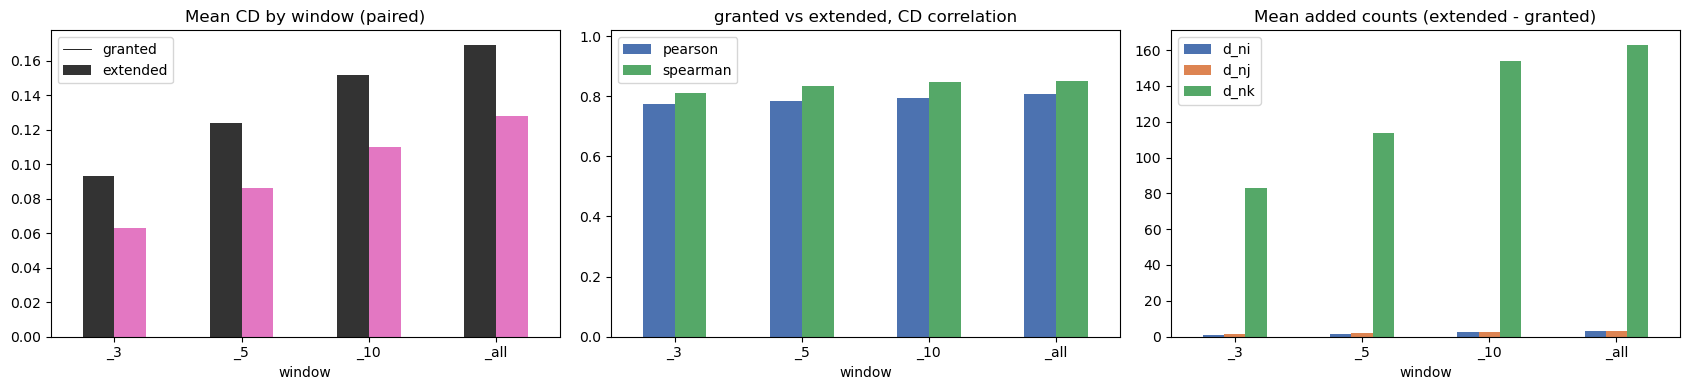

In [6]:
rows = []
for s in WSFX:
    xb, xa = col(BASE_FP, f'CD{s}')[ub], col(APP_FP, f'CD{s}')[ua]
    k = ~np.isnan(xb) & ~np.isnan(xa)
    x, y = xb[k], xa[k]; z = y - x
    # Spearman over ~6M rows is a full argsort per column; a 1M sample is stable to ~3 decimals.
    rng = np.random.default_rng(0)
    sm = rng.choice(len(x), size=min(1_000_000, len(x)), replace=False)
    sp = pd.DataFrame({'x': x[sm], 'y': y[sm]}).corr(method='spearman').iloc[0, 1]
    r = {'window': s, 'n_paired': int(k.sum()), 'base_mean': x.mean(), 'app_mean': y.mean(),
         'delta': z.mean(), 'pearson': np.corrcoef(x, y)[0, 1], 'spearman': sp,
         'pct_down': 100*(z < 0).mean(), 'pct_up': 100*(z > 0).mean(), 'pct_same': 100*(z == 0).mean()}
    for nm in ['ni', 'nj', 'nk']:
        yb, ya = col(BASE_FP, f'{nm}{s}')[ub], col(APP_FP, f'{nm}{s}')[ua]
        r[f'd_{nm}'] = np.nanmean(ya[k] - yb[k])
    rows.append(r); del xb, xa, x, y, z; gc.collect()
win = pd.DataFrame(rows).set_index('window')
display(win)

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
win[['base_mean', 'app_mean']].plot.bar(ax=ax[0], color=[C_B, C_A])
ax[0].set_title('Mean CD by window (paired)'); ax[0].axhline(0, color='k', lw=0.6)
ax[0].legend(['granted', 'extended']); ax[0].tick_params(axis='x', rotation=0)
win[['pearson', 'spearman']].plot.bar(ax=ax[1], color=['#4c72b0', '#55a868'])
ax[1].set_ylim(0, 1.02); ax[1].set_title('granted vs extended, CD correlation')
ax[1].tick_params(axis='x', rotation=0)
win[['d_ni', 'd_nj', 'd_nk']].plot.bar(ax=ax[2], color=['#4c72b0', '#dd8452', '#55a868'])
ax[2].set_title('Mean added counts (extended - granted)'); ax[2].axhline(0, color='k', lw=0.6)
ax[2].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 6. F / E / G shares

`F` (Foundation), `E` (Extension), `G` (Generalization) are shares of a patent's citers and sum to 1, so
they describe *how* the citing crowd changes when application citations are added — independently of the
level shift in CD.

,granted,extended,delta
F (foundation),0.0514,0.1073,0.0558
E (extension),0.3414,0.3512,0.0099
G (generalization),0.6072,0.5415,-0.0657


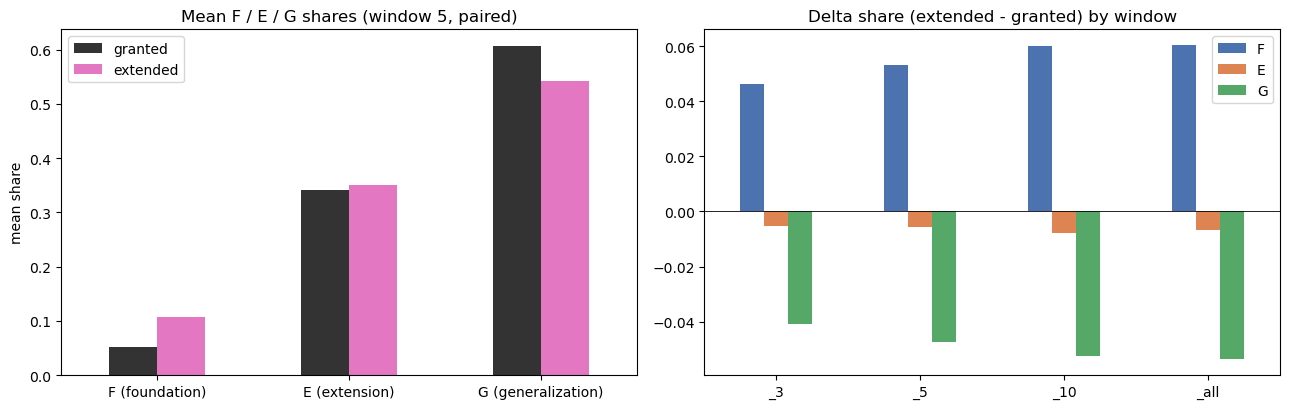

In [7]:
feg = pd.DataFrame({'granted':  [np.nanmean(col(BASE_FP, f'{m}{MAIN}')[ub][ok]) for m in 'FEG'],
                    'extended': [np.nanmean(col(APP_FP,  f'{m}{MAIN}')[ua][ok]) for m in 'FEG']},
                   index=['F (foundation)', 'E (extension)', 'G (generalization)'])
feg['delta'] = feg['extended'] - feg['granted']
display(feg)

dw = pd.DataFrame({m: [np.nanmean(col(APP_FP, f'{m}{s}')) - np.nanmean(col(BASE_FP, f'{m}{s}')) for s in WSFX]
                   for m in 'FEG'}, index=WSFX)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
feg[['granted', 'extended']].plot.bar(ax=ax[0], color=[C_B, C_A])
ax[0].set_title(f'Mean F / E / G shares (window {MAIN.strip("_")}, paired)')
ax[0].set_ylabel('mean share'); ax[0].tick_params(axis='x', rotation=0)
dw.plot.bar(ax=ax[1], color=['#4c72b0', '#dd8452', '#55a868'])
ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_title('Delta share (extended - granted) by window'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 7. Window 5 — CD by CPC section

Sections differ a lot in how much of their citation traffic is pre-grant (software and biotech publish,
and get cited, before grant far more than mechanical fields do), so the granted/extended gap should not
be uniform across sections.

`A` human necessities · `B` operations, transport · `C` chemistry, metallurgy · `D` textiles · `E` fixed
constructions · `F` mechanical engineering · `G` physics · `H` electricity · `Y` cross-sectional tagging

,CD_granted,CD_extended,n,delta
sect,,,,
A,0.0798,0.0624,775197,-0.0174
B,0.1176,0.0984,854031,-0.0192
C,0.1650,0.1466,571475,-0.0184
D,0.1555,0.1473,56150,-0.0081
E,0.0937,0.0829,170977,-0.0108
F,0.1201,0.1033,453567,-0.0168
G,0.1206,0.0708,1501743,-0.0499
H,0.1430,0.0754,1384683,-0.0676


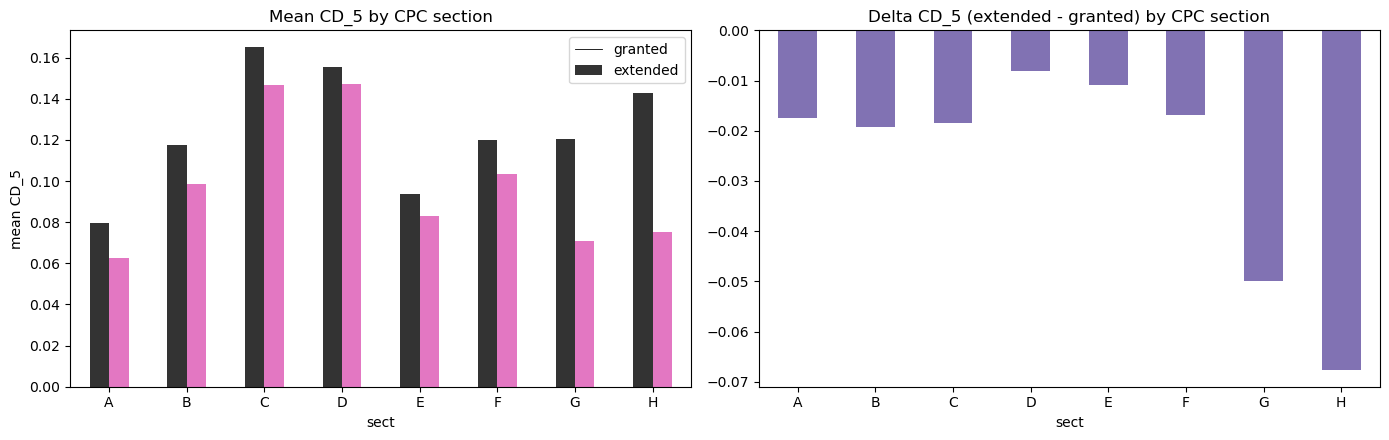

19351

In [8]:
m5 = pd.DataFrame({'CD_b': cb, 'CD_a': ca, 'sect': sect[ok]})
m5 = m5[m5['sect'] != '']
gs = m5.groupby('sect').agg(CD_granted=('CD_b', 'mean'), CD_extended=('CD_a', 'mean'), n=('CD_b', 'size'))
gs['delta'] = gs['CD_extended'] - gs['CD_granted']
display(gs)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
gs[['CD_granted', 'CD_extended']].plot.bar(ax=ax[0], color=[C_B, C_A])
ax[0].set_title(f'Mean CD{MAIN} by CPC section'); ax[0].set_ylabel(f'mean CD{MAIN}')
ax[0].axhline(0, color='k', lw=0.6); ax[0].legend(['granted', 'extended']); ax[0].tick_params(axis='x', rotation=0)
gs['delta'].plot.bar(ax=ax[1], color=C_D); ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_title(f'Delta CD{MAIN} (extended - granted) by CPC section'); ax[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
del m5; gc.collect()

## 8. CD trend by grant year

The decisive plot. Applications were not published before **2001**, so up to then the extended network
*is* the granted network and the two curves must coincide. Any gap that opens after 2001 is the
measurement effect of ignoring application citations — not a change in invention.

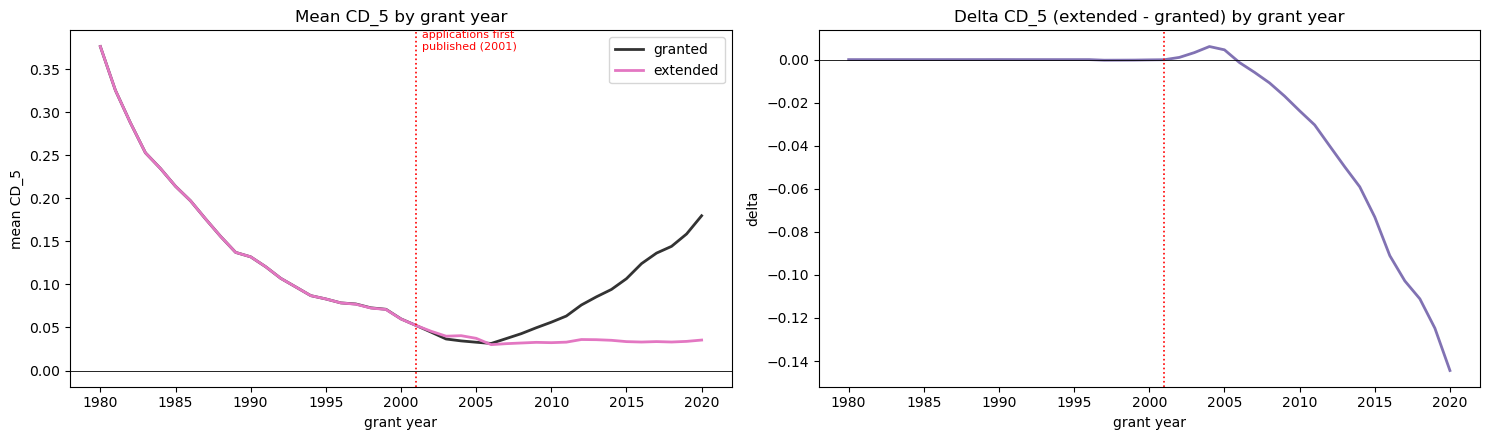

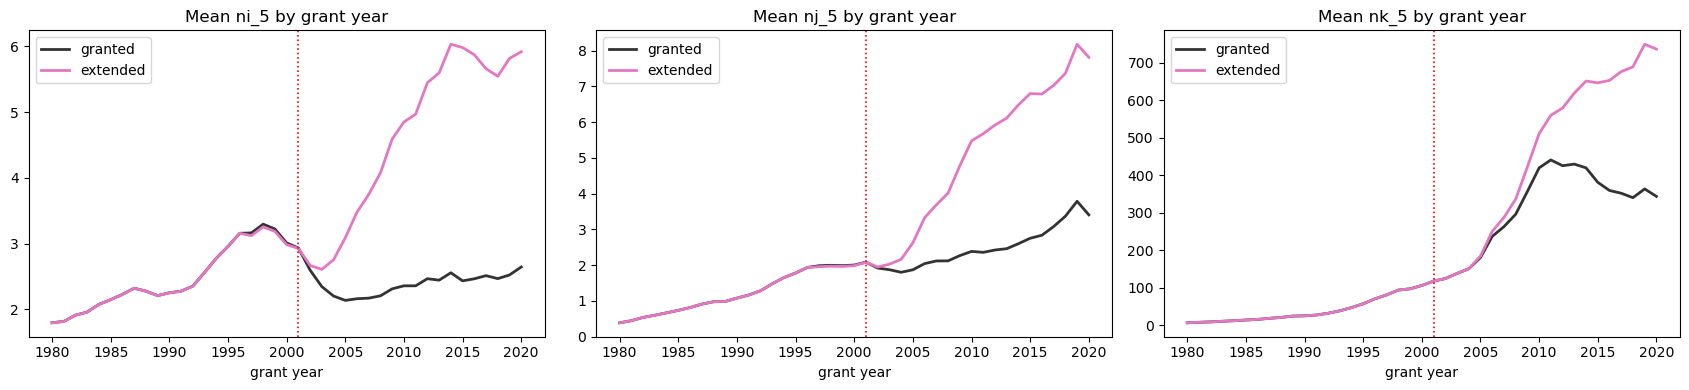

,CD_b,CD_a,n,delta
year,,,,
1990,0.1321,0.1321,84523,0.0000
1995,0.0831,0.0831,96894,0.0000
2000,0.0600,0.0599,149488,-0.0001
2001,0.0524,0.0523,156844,-0.0000
2003,0.0366,0.0399,156894,0.0033
2005,0.0329,0.0374,130277,0.0045
2010,0.0561,0.0324,180929,-0.0238
2015,0.1067,0.0336,198501,-0.0731
2020,0.1798,0.0354,166669,-0.1444


15780

In [9]:
tr = pd.DataFrame({'year': gyear[ok], 'CD_b': cb, 'CD_a': ca})
for nm in ['ni', 'nj', 'nk']:
    xb, xa = paired(nm)
    tr[f'{nm}_b'], tr[f'{nm}_a'] = xb[ok], xa[ok]
tr = tr[(tr['year'] >= 1980) & (tr['year'] <= 2020)]
g = tr.groupby('year').agg(CD_b=('CD_b', 'mean'), CD_a=('CD_a', 'mean'), n=('CD_b', 'size'))
g['delta'] = g['CD_a'] - g['CD_b']

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
g['CD_b'].plot(ax=ax[0], color=C_B, lw=2, label='granted')
g['CD_a'].plot(ax=ax[0], color=C_A, lw=2, label='extended')
ax[0].axhline(0, color='k', lw=0.6); ax[0].axvline(2001, color='r', ls=':', lw=1.2)
ax[0].annotate('applications first\npublished (2001)', xy=(2001.4, ax[0].get_ylim()[1]),
               va='top', fontsize=8, color='r')
ax[0].set_title(f'Mean CD{MAIN} by grant year'); ax[0].set_ylabel(f'mean CD{MAIN}')
ax[0].set_xlabel('grant year'); ax[0].legend()
g['delta'].plot(ax=ax[1], color=C_D, lw=2)
ax[1].axhline(0, color='k', lw=0.6); ax[1].axvline(2001, color='r', ls=':', lw=1.2)
ax[1].set_title(f'Delta CD{MAIN} (extended - granted) by grant year')
ax[1].set_ylabel('delta'); ax[1].set_xlabel('grant year')
plt.tight_layout(); plt.show()

nn = tr.groupby('year')[[f'{nm}_{t}' for nm in ['ni', 'nj', 'nk'] for t in 'ba']].mean()
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
for k, nm in enumerate(['ni', 'nj', 'nk']):
    nn[f'{nm}_b'].plot(ax=ax[k], color=C_B, lw=2, label='granted')
    nn[f'{nm}_a'].plot(ax=ax[k], color=C_A, lw=2, label='extended')
    ax[k].axvline(2001, color='r', ls=':', lw=1.2)
    ax[k].set_title(f'Mean {nm}{MAIN} by grant year'); ax[k].set_xlabel('grant year'); ax[k].legend()
plt.tight_layout(); plt.show()

yrs = [y for y in [1990, 1995, 2000, 2001, 2003, 2005, 2010, 2015, 2020] if y in g.index]
display(g.loc[yrs])
del tr, nn; gc.collect()

## 9. Where the two disagree most

The tail of the shift distribution: patents whose CD moves furthest when application citations are added.
Restricted to patents with at least 10 citers in **both** networks. With a denominator of 2 or 3 a
single added edge swings CD by half its range, and requiring the floor in the extended network alone is
not enough: the tail then fills with patents that simply had one citer before application citations were
counted, which is a statement about coverage, not about disagreement between two comparable measurements.

patents with >=10 citers in BOTH networks: 549,850

largest INCREASE in CD_5  (more disruptive once application citations are counted):


,patent_id,CD_granted,CD_extended,dCD,ni_b,ni_a,nj_b,nj_a,nk_b,nk_a
0,8110251,-0.4706,0.8918,1.3624,1.0000,252.0000,9.0000,13.0000,7.0000,3.0000
1,7939664,-0.5500,0.7954,1.3454,0.0000,220.0000,11.0000,14.0000,9.0000,25.0000
2,8440055,-0.5806,0.5349,1.1155,0.0000,89.0000,18.0000,20.0000,13.0000,20.0000
3,8467275,-0.9091,0.1250,1.0341,0.0000,28.0000,10.0000,10.0000,1.0000,106.0000
4,9386553,-0.5385,0.4658,1.0042,1.0000,48.0000,15.0000,14.0000,10.0000,11.0000
5,9818370,-1.0000,-0.0125,0.9875,0.0000,1.0000,12.0000,12.0000,0.0000,870.0000
6,9769078,-0.9545,0.0303,0.9848,0.0000,24.0000,21.0000,22.0000,1.0000,20.0000
7,11017942,-1.0000,-0.0212,0.9788,0.0000,3.0000,11.0000,11.0000,0.0000,364.0000
8,10335624,-0.5789,0.3934,0.9724,1.0000,41.0000,12.0000,17.0000,6.0000,3.0000
9,11002994,-1.0000,-0.0485,0.9515,0.0000,0.0000,15.0000,15.0000,0.0000,294.0000



largest DECREASE in CD_5  (more consolidating once application citations are counted):


,patent_id,CD_granted,CD_extended,dCD,ni_b,ni_a,nj_b,nj_a,nk_b,nk_a
0,9493455,1.0000,-1.0000,-2.0000,16.0000,0.0000,0.0000,16.0000,0.0000,0.0000
1,7060475,1.0000,-1.0000,-2.0000,11.0000,0.0000,0.0000,23.0000,0.0000,0.0000
2,7029893,1.0000,-1.0000,-2.0000,11.0000,0.0000,0.0000,23.0000,0.0000,0.0000
3,7026149,1.0000,-1.0000,-2.0000,11.0000,0.0000,0.0000,23.0000,0.0000,0.0000
4,8293181,1.0000,-0.9375,-1.9375,15.0000,0.0000,0.0000,15.0000,0.0000,1.0000
5,7674797,1.0000,-0.9231,-1.9231,12.0000,0.0000,0.0000,12.0000,0.0000,1.0000
6,9496189,1.0000,-0.9224,-1.9224,528.0000,4.0000,0.0000,527.0000,0.0000,36.0000
7,12030915,1.0000,-0.9167,-1.9167,10.0000,0.0000,0.0000,11.0000,0.0000,1.0000
8,9266827,1.0000,-0.9167,-1.9167,22.0000,0.0000,0.0000,22.0000,0.0000,2.0000
9,8802658,1.0000,-0.9009,-1.9009,93.0000,0.0000,0.0000,100.0000,0.0000,11.0000


,n,mean_dCD,CD_granted,CD_extended
citers,,,,
10-15,211403,-0.0226,0.0965,0.0739
16-25,150395,-0.0361,0.0812,0.0451
26-50,114353,-0.0487,0.0772,0.0285
51-100,49004,-0.0605,0.0782,0.0177
101-250,19290,-0.0732,0.0845,0.0113
250+,5405,-0.0534,0.0220,-0.0314


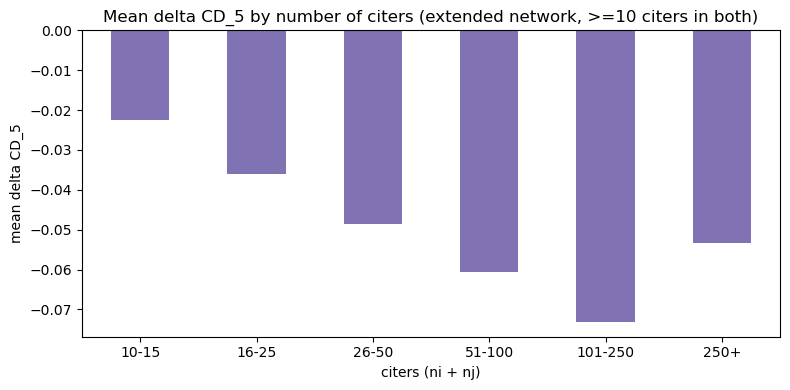

peak RSS: 2.30 GB


In [10]:
nib, nia = paired('ni'); njb, nja = paired('nj'); nkb, nka = paired('nk')
ni_b, nj_b = nib[ok], njb[ok]
ni_a, nj_a = nia[ok], nja[ok]
sel = np.flatnonzero(((ni_b + nj_b) >= 10) & ((ni_a + nj_a) >= 10))   # positions in the CD-defined set
print(f'patents with >=10 citers in BOTH networks: {len(sel):,}')

# patent_id is only fetched for the ~30 rows actually displayed. Building it for all
# 5.8M would mean 5.8M Python strings, which is what OOM-kills the kernel under the
# 8 GiB login-node cap -- the numbers below stay in numpy until the last moment.
codes_ok = both_code[ok]
def movers(pos):
    return pd.DataFrame({
        'patent_id':   uni.take(pa.array(codes_ok[pos])).to_pylist(),
        'CD_granted':  cb[pos], 'CD_extended': ca[pos], 'dCD': dd[pos],
        'ni_b': ni_b[pos], 'ni_a': ni_a[pos], 'nj_b': nj_b[pos], 'nj_a': nj_a[pos],
        'nk_b': nkb[ok][pos], 'nk_a': nka[ok][pos]})

order = np.argsort(dd[sel])
print(f'\nlargest INCREASE in CD{MAIN}  (more disruptive once application citations are counted):')
display(movers(sel[order[-15:][::-1]]))
print(f'\nlargest DECREASE in CD{MAIN}  (more consolidating once application citations are counted):')
display(movers(sel[order[:15]]))
del order; gc.collect()

# Does the shift depend on how well cited a patent is?
bins = pd.cut(ni_a[sel] + nj_a[sel], [9, 15, 25, 50, 100, 250, 10**9],
              labels=['10-15', '16-25', '26-50', '51-100', '101-250', '250+'])
bb = pd.DataFrame({'citers': bins, 'dCD': dd[sel], 'CD_b': cb[sel], 'CD_a': ca[sel]}).groupby(
        'citers', observed=True).agg(n=('dCD', 'size'), mean_dCD=('dCD', 'mean'),
                                     CD_granted=('CD_b', 'mean'), CD_extended=('CD_a', 'mean'))
display(bb)
fig, ax = plt.subplots(figsize=(8, 4))
bb['mean_dCD'].plot.bar(ax=ax, color=C_D); ax.axhline(0, color='k', lw=0.6)
ax.set_title(f'Mean delta CD{MAIN} by number of citers (extended network, >=10 citers in both)')
ax.set_xlabel('citers (ni + nj)'); ax.set_ylabel(f'mean delta CD{MAIN}')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()
del nib, nia, njb, nja, nkb, nka, ni_b, nj_b, ni_a, nj_a, sel, bins, codes_ok; gc.collect()
print(f'peak RSS: {rss_gb():.2f} GB')

## 10. Save the comparison summary

One small parquet with the per-window paired statistics, so the comparison can be cited without
re-loading two multi-GB tables.

**File:** `/project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption_compare.parquet`

In [11]:
summary = win.reset_index()
summary.insert(1, 'n_base_rows', n_b); summary.insert(2, 'n_app_rows', n_a)
summary.insert(3, 'n_app_only', n_only_a)
summary.to_parquet(CMP_FP, index=False)
print(f'WROTE {CMP_FP}  ({len(summary):,} rows, {len(summary.columns)} cols)')
display(summary)

print()
print(f'coverage  : base {n_b:,} rows | app {n_a:,} rows | both {n_both:,} | '
      f'base-only {n_only_b:,} | app-only {n_only_a:,}')
print(f'window {MAIN.strip("_")}  : mean CD {cb.mean():+.4f} -> {ca.mean():+.4f}   (delta {dd.mean():+.4f}, '
      f'pearson {win.loc[MAIN, "pearson"]:.4f}, spearman {win.loc[MAIN, "spearman"]:.4f})')
print(f'shift     : {win.loc[MAIN, "pct_down"]:.1f}% down / {win.loc[MAIN, "pct_up"]:.1f}% up / '
      f'{win.loc[MAIN, "pct_same"]:.1f}% unchanged')
print(f'peak RSS  : {rss_gb():.2f} GB')

WROTE /project/jevans/Dawoon/Science of Science/PatentView/output/patent_disruption_compare.parquet  (4 rows, 16 cols)


,window,n_base_rows,n_app_rows,n_app_only,n_paired,base_mean,app_mean,delta,pearson,spearman,pct_down,pct_up,pct_same,d_ni,d_nj,d_nk
0,_3,8062166,8460168,398002,5606555,0.0933,0.0632,-0.0301,0.7760,0.8107,23.1352,20.0828,56.7820,0.8988,1.2262,83.1845
1,_5,8062166,8460168,398002,5768230,0.1240,0.0860,-0.0379,0.7831,0.8347,26.8537,22.1737,50.9726,1.4635,1.7913,113.6352
2,_10,8062166,8460168,398002,5899905,0.1517,0.1098,-0.0419,0.7944,0.8477,29.0272,24.2136,46.7592,2.4456,2.7026,153.7182
3,_all,8062166,8460168,398002,5973424,0.1691,0.1279,-0.0411,0.8078,0.8503,29.4630,25.5739,44.9631,3.0262,3.0910,162.8686



coverage  : base 8,062,166 rows | app 8,460,168 rows | both 8,062,166 | base-only 0 | app-only 398,002
window 5  : mean CD +0.1240 -> +0.0860   (delta -0.0379, pearson 0.7831, spearman 0.8347)
shift     : 26.9% down / 22.2% up / 51.0% unchanged
peak RSS  : 2.30 GB
